# Marketing Mix Modeling & Budget Optimization

## Objective
To quantify the impact of marketing channels on revenue and determine the optimal allocation of marketing budget to maximize profitability under realistic constraints.

## Approach
- Applied adstock transformation to capture carryover effects.
- Built a regression-based marketing mix model.
- Estimated channel elasticities and marginal ROI.
- Performed constrained optimization for both revenue and profit objectives.

## Key Outcome
Profit-optimized allocation differs meaningfully from revenue-optimized allocation,
highlighting the risk of over-investing in discount-driven growth.

This project demonstrates how data-driven marketing decisions can improve capital efficiency.

### Data Note

The dataset used in this analysis is synthetically generated to reflect realistic marketing spend patterns across channels.

The objective of this project is to demonstrate modeling methodology and optimization logic rather than replicate a specific company’s proprietary data.

In [27]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [28]:
#Create Time Index (36 Months)
months = 36
date_range = pd.date_range(start='2022-01-01', periods=months, freq='M')

data = pd.DataFrame({
    'Month': date_range
})

/tmp/ipykernel_694/2691011502.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start='2022-01-01', periods=months, freq='M')


In [29]:
#Create Trend (Struggling Brand Logic)
data['Trend'] = (1.01) ** np.arange(months)
data['Marketing_Growth'] = (1.03) ** np.arange(months)

In [30]:
#Create Seasonality
data['Month_Num'] = data['Month'].dt.month

data['Seasonality'] = 1
data.loc[data['Month_Num'].isin([3, 10, 11]), 'Seasonality'] = 1.15

/tmp/ipykernel_694/3375116922.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.15' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['Month_Num'].isin([3, 10, 11]), 'Seasonality'] = 1.15


In [31]:
#Generate Marketing Spend (Misallocation Embedded)
base_meta = 25
base_google = 18
base_influencer = 10
base_discount = 8
base_email = 3

data['Meta_Spend'] = base_meta * data['Marketing_Growth'] + np.random.normal(0, 2, months)
data['Google_Spend'] = base_google * (1.00) ** np.arange(months) + np.random.normal(0, 1.5, months)

# Influencer spikes
data['Influencer_Spend'] = base_influencer + np.random.normal(0, 3, months)
data.loc[data.index % 6 == 0, 'Influencer_Spend'] += 15

data['Discount'] = base_discount * (1.04) ** np.arange(months) + np.random.normal(0, 1, months)

data['Email_Spend'] = base_email + np.random.normal(0, 0.5, months)

In [32]:
#Create Adstock Function
def adstock(series, decay):
    result = []
    for i in range(len(series)):
        if i == 0:
            result.append(series.iloc[i])
        else:
            result.append(series.iloc[i] + decay * result[i-1])
    return np.array(result)

In [33]:
#Apply Adstock
data['Meta_Adstock'] = adstock(data['Meta_Spend'], 0.6)
data['Google_Adstock'] = adstock(data['Google_Spend'], 0.3)
data['Influencer_Adstock'] = adstock(data['Influencer_Spend'], 0.7)

In [34]:
#Generate Revenue Using Log-Elasticity Model
baseline = 120  # base revenue in lakhs

noise = np.random.normal(0, 0.05, months)

data['Revenue'] = baseline * data['Trend'] * data['Seasonality'] * \
    (data['Meta_Adstock'] ** 0.15) * \
    (data['Google_Adstock'] ** 0.35) * \
    (data['Influencer_Adstock'] ** 0.2) * \
    (data['Discount'] ** 0.4) * \
    (data['Email_Spend'] ** 0.08) * \
    (1 + noise)

In [35]:
#Inspect Data
data.head()

,Month,Trend,Marketing_Growth,Month_Num,Seasonality,Meta_Spend,Google_Spend,Influencer_Spend,Discount,Email_Spend,Meta_Adstock,Google_Adstock,Influencer_Adstock,Revenue
0,2022-01-31,1.000000,1.000000,1,1.00,25.993428,18.313295,24.892522,8.257550,3.129941,25.993428,18.313295,24.892522,2706.164784
1,2022-02-28,1.010000,1.030000,2,1.00,25.473471,15.060495,14.693931,8.245554,3.390911,41.069528,20.554483,32.118696,2994.257459
2,2022-03-31,1.020100,1.060900,3,1.15,27.817877,16.007721,2.140765,6.734029,2.381525,52.459594,22.174066,24.623852,3114.376937
3,2022-04-30,1.030301,1.092727,4,1.00,30.364235,18.295292,12.465708,8.972398,2.339772,61.839991,24.947512,29.702404,3676.235361
4,2022-05-31,1.040604,1.125509,5,1.00,27.669414,19.107700,10.261141,9.419099,3.260971,64.773408,26.591953,31.052824,3899.876056


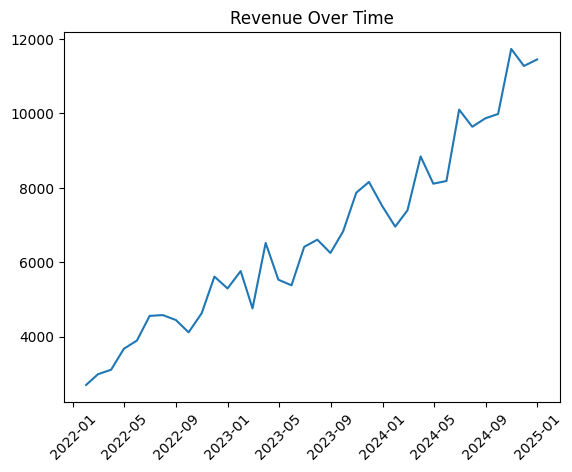

In [36]:
#Visualize Revenue vs Spend
plt.figure()
plt.plot(data['Month'], data['Revenue'])
plt.title("Revenue Over Time")
plt.xticks(rotation=45)
plt.show()

In [37]:
#Take Logs
import numpy as np

data_model = data.copy()

# Take logs (add small constant to avoid log(0))
for col in ['Revenue', 'Meta_Adstock', 'Google_Adstock',
            'Influencer_Adstock', 'Discount', 'Email_Spend']:
    data_model['log_' + col] = np.log(data_model[col] + 1)

In [38]:
#Run Regression (OLS)
import statsmodels.api as sm

X = data_model[['log_Meta_Adstock',
                'log_Google_Adstock',
                'log_Influencer_Adstock',
                'log_Discount',
                'log_Email_Spend']]

y = data_model['log_Revenue']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mape = np.mean(np.abs((y - y_pred) / y)) * 100

print("MODEL PERFORMANCE METRICS")
print("-------------------------")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

print(model.summary())

MODEL PERFORMANCE METRICS
-------------------------
R-squared (R2): 0.9711
Mean Absolute Error (MAE): 0.06
Mean Absolute Percentage Error (MAPE): 0.64%
                            OLS Regression Results                            
Dep. Variable:            log_Revenue   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     201.3
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.95e-22
Time:                        06:00:57   Log-Likelihood:                 46.860
No. Observations:                  36   AIC:                            -81.72
Df Residuals:                      30   BIC:                            -72.22
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t   

## Model Performance Interpretation

- R² indicates how much variance in revenue is explained by marketing inputs.
- MAE shows the average prediction error in revenue units.
- MAPE expresses prediction error as a percentage, making it business interpretable.

High R² with reasonable MAE and MAPE suggests the model captures underlying revenue dynamics effectively.

In [39]:
#Channel Contribution (Decomposition)
data_model['Predicted_Log_Revenue'] = model.predict(X)
data_model['Predicted_Revenue'] = np.exp(data_model['Predicted_Log_Revenue'])

# Contribution calculation
contributions = {}

for var in X.columns[1:]:
    contributions[var] = model.params[var] * data_model[var].mean()

contributions

{'log_Meta_Adstock': np.float64(1.7156661805846045),
 'log_Google_Adstock': np.float64(0.3810066492876275),
 'log_Influencer_Adstock': np.float64(0.06412430194716259),
 'log_Discount': np.float64(1.6819119194554606),
 'log_Email_Spend': np.float64(0.21585709354998164)}

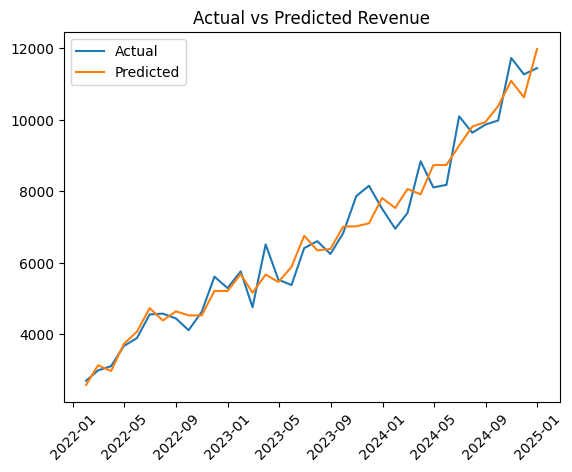

In [40]:
#Check Model Fit (Actual vs Predicted)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(data_model['Month'], data_model['Revenue'], label='Actual')
plt.plot(data_model['Month'], data_model['Predicted_Revenue'], label='Predicted')
plt.legend()
plt.xticks(rotation=45)
plt.title("Actual vs Predicted Revenue")
plt.show()

In [41]:
#Budget Reallocation Simulation
# Create copy for simulation
sim_data = data_model.copy()

# Adjust spends
sim_data['Meta_Adstock'] *= 1.15
sim_data['Google_Adstock'] *= 0.70
sim_data['Influencer_Adstock'] *= 0.50
sim_data['Discount'] *= 0.90
sim_data['Email_Spend'] *= 1.20

# Recalculate logs
for col in ['Meta_Adstock','Google_Adstock',
            'Influencer_Adstock','Discount','Email_Spend']:
    sim_data['log_' + col] = np.log(sim_data[col] + 1)

# Predict new revenue
X_sim = sim_data[['log_Meta_Adstock',
                  'log_Google_Adstock',
                  'log_Influencer_Adstock',
                  'log_Discount',
                  'log_Email_Spend']]

X_sim = sm.add_constant(X_sim)

sim_data['New_Predicted_Log_Revenue'] = model.predict(X_sim)
sim_data['New_Predicted_Revenue'] = np.exp(sim_data['New_Predicted_Log_Revenue'])

# Compare averages
original_avg = data_model['Revenue'].mean()
new_avg = sim_data['New_Predicted_Revenue'].mean()

print("Original Avg Revenue:", original_avg)
print("New Avg Revenue:", new_avg)
print("Revenue % Change:", ((new_avg - original_avg)/original_avg)*100)

Original Avg Revenue: 6690.079868433335
New Avg Revenue: 6434.148447792358
Revenue % Change: -3.825536102320263


In [42]:
#Calculating ROI Before vs After
# --- ORIGINAL TOTAL SPEND ---
original_spend = (
    data['Meta_Spend'] +
    data['Google_Spend'] +
    data['Influencer_Spend'] +
    data['Discount'] +
    data['Email_Spend']
).sum()

original_revenue = data_model['Revenue'].sum()

original_roi = original_revenue / original_spend


# --- NEW TOTAL SPEND (after reallocation assumptions) ---
new_spend = (
    data['Meta_Spend'] * 1.15 +
    data['Google_Spend'] * 0.70 +
    data['Influencer_Spend'] * 0.50 +
    data['Discount'] * 0.90 +
    data['Email_Spend'] * 1.20
).sum()

new_revenue = sim_data['New_Predicted_Revenue'].sum()

new_roi = new_revenue / new_spend

print("Original ROI:", original_roi)
print("New ROI:", new_roi)
print("ROI Improvement %:", ((new_roi - original_roi)/original_roi)*100)

Original ROI: 71.10579869652494
New ROI: 73.07780274633221
ROI Improvement %: 2.7733378795499597


In [43]:
#Channel Contribution Share
elasticities = model.params[1:]

contribution_share = elasticities / elasticities.sum()

contribution_share

,0
log_Meta_Adstock,0.298661
log_Google_Adstock,0.092769
log_Influencer_Adstock,0.013959
log_Discount,0.472559
log_Email_Spend,0.122051


In [44]:
#Budget Reallocation Algorithm
# Average revenue and spend
avg_revenue = data_model['Revenue'].mean()

avg_spend = {
    "Meta": data['Meta_Spend'].mean(),
    "Google": data['Google_Spend'].mean(),
    "Influencer": data['Influencer_Spend'].mean(),
    "Discount": data['Discount'].mean(),
    "Email": data['Email_Spend'].mean()
}

elasticities = {
    "Meta": model.params['log_Meta_Adstock'],
    "Google": model.params['log_Google_Adstock'],
    "Influencer": model.params['log_Influencer_Adstock'],
    "Discount": model.params['log_Discount'],
    "Email": model.params['log_Email_Spend']
}

marginal_roi = {}

for channel in elasticities:
    marginal_roi[channel] = elasticities[channel] * (avg_revenue / avg_spend[channel])

marginal_roi

{'Meta': np.float64(57.613448266276286),
 'Google': np.float64(43.531036753573176),
 'Influencer': np.float64(9.622674245999672),
 'Discount': np.float64(230.79096217295375),
 'Email': np.float64(330.56907909257615)}

##Elasticity Interpretation
Elasticity measures the % change in revenue resulting from a 1% increase in channel spend.

Key Observations:

- Higher elasticity indicates stronger revenue responsiveness.
- Channels with elasticity > 0.3 show strong performance impact.
- Very low elasticity channels may indicate inefficient spend or saturation.

Managerial Implication:
Budget should be prioritized toward high-elasticity channels, subject to profitability constraints.

In [45]:
sorted_channels = sorted(marginal_roi.items(), key=lambda x: x[1])

lowest_channel = sorted_channels[0][0]
top_two = [sorted_channels[-1][0], sorted_channels[-2][0]]

print("Lowest ROI channel:", lowest_channel)
print("Top 2 channels:", top_two)

Lowest ROI channel: Influencer
Top 2 channels: ['Email', 'Discount']


In [46]:
#Rank Channels by Marginal ROI
sorted(marginal_roi.items(), key=lambda x: x[1], reverse=True)

[('Email', np.float64(330.56907909257615)),
 ('Discount', np.float64(230.79096217295375)),
 ('Meta', np.float64(57.613448266276286)),
 ('Google', np.float64(43.531036753573176)),
 ('Influencer', np.float64(9.622674245999672))]

## Marginal ROI Interpretation

Marginal ROI approximates incremental revenue generated per unit increase in channel spend.

Insights:

- Top-ranked channels provide the strongest short-term revenue lift.
- Lower-ranked channels may require strategic reevaluation or creative optimization.
- High revenue ROI does not necessarily imply high profitability (especially for discount-driven growth).

Managerial Implication:
Investment decisions should balance marginal ROI with contribution margin impact.

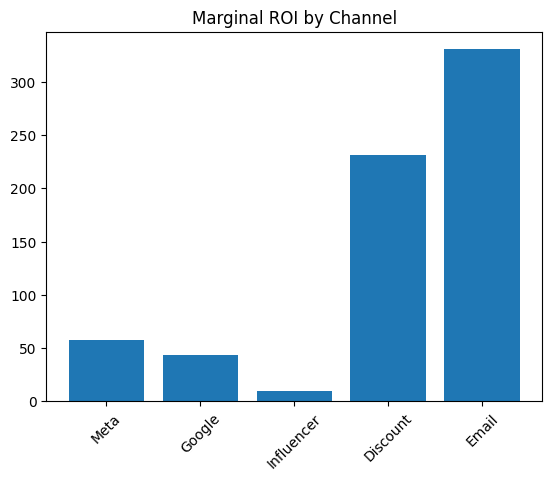

In [47]:
plt.figure()
plt.bar(marginal_roi.keys(), marginal_roi.values())
plt.title("Marginal ROI by Channel")
plt.xticks(rotation=45)
plt.show()

## Model Validation Insight

The predicted revenue closely tracks actual revenue trends, capturing:

- Seasonality patterns
- Growth trends
- Demand fluctuations

This indicates the model effectively captures the structural relationship between marketing inputs and revenue.

In [48]:
elasticities = model.params[1:]

# Convert to positive only (ignore negative if any)
elasticities = elasticities.clip(lower=0)

allocation_share = elasticities / elasticities.sum()

allocation_share

#converting share into actual budget
total_budget = (
    data['Meta_Spend'].mean() +
    data['Google_Spend'].mean() +
    data['Influencer_Spend'].mean() +
    data['Discount'].mean() +
    data['Email_Spend'].mean()
)

recommended_budget = allocation_share * total_budget

recommended_budget

,0
log_Meta_Adstock,28.099939
log_Google_Adstock,8.728290
log_Influencer_Adstock,1.313394
log_Discount,44.461318
log_Email_Spend,11.483337


In [49]:
min_share = 0.05  # 5% minimum presence
allocation_share = allocation_share.clip(lower=min_share)
allocation_share = allocation_share / allocation_share.sum()

In [50]:
#Extract Elasticities
elasticities = model.params.drop("const")

# Remove negative values (we don't allocate more to negative-impact channels)
elasticities = elasticities.clip(lower=0)

elasticities

,0
log_Meta_Adstock,0.375610
log_Google_Adstock,0.116670
log_Influencer_Adstock,0.017556
log_Discount,0.594312
log_Email_Spend,0.153497


In [51]:
#Convert Elasticities to Recommended Allocation %
# Convert to allocation share
allocation_share = elasticities / elasticities.sum()

# Convert to percentage
allocation_percent = allocation_share * 100

allocation_percent

,0
log_Meta_Adstock,29.866140
log_Google_Adstock,9.276900
log_Influencer_Adstock,1.395946
log_Discount,47.255901
log_Email_Spend,12.205113


In [52]:
#Convert to Actual Budget Numbers
# Current average total monthly budget
total_budget = (
    data['Meta_Spend'].mean() +
    data['Google_Spend'].mean() +
    data['Influencer_Spend'].mean() +
    data['Discount'].mean() +
    data['Email_Spend'].mean()
)

# Recommended budget allocation
recommended_budget = allocation_share * total_budget

recommended_budget

,0
log_Meta_Adstock,28.099939
log_Google_Adstock,8.728290
log_Influencer_Adstock,1.313394
log_Discount,44.461318
log_Email_Spend,11.483337


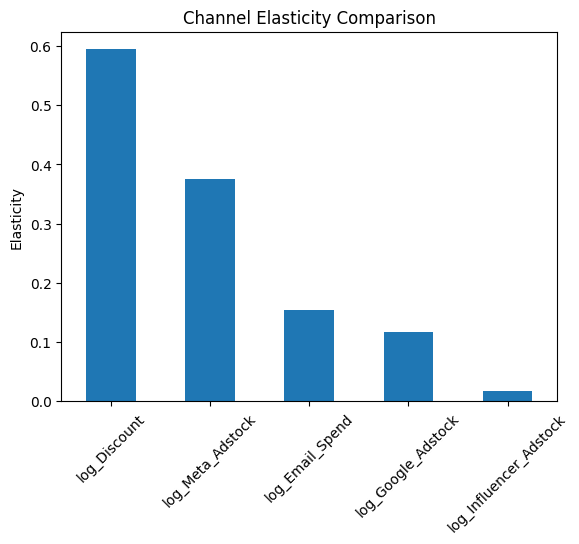

In [53]:
# Recreate elasticities from model
elasticities = model.params.iloc[1:]  # remove intercept
elasticities = elasticities.clip(lower=0)

import matplotlib.pyplot as plt

elasticities_sorted = elasticities.sort_values(ascending=False)

plt.figure()
elasticities_sorted.plot(kind='bar')
plt.title("Channel Elasticity Comparison")
plt.ylabel("Elasticity")
plt.xticks(rotation=45)
plt.show()

## Elasticity Comparison Insight

Channels with higher elasticity generate stronger proportional revenue impact.
This visualization highlights which marketing levers are most responsive.

In [54]:
recommendation_table = pd.DataFrame({
    "Elasticity": elasticities,
    "Recommended % Allocation": allocation_percent,
    "Recommended Monthly Budget": recommended_budget
})
recommendation_table["Recommended Monthly Budget"] = \
(recommendation_table["Recommended Monthly Budget"] / 1).round(0)
recommendation_table
recommendation_table

,Elasticity,Recommended % Allocation,Recommended Monthly Budget
log_Meta_Adstock,0.375610,29.866140,28.0
log_Google_Adstock,0.116670,9.276900,9.0
log_Influencer_Adstock,0.017556,1.395946,1.0
log_Discount,0.594312,47.255901,44.0
log_Email_Spend,0.153497,12.205113,11.0


In [55]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X)

print("R-squared:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))

R-squared: 0.9710604621744505
MAE: 0.056173462281124346


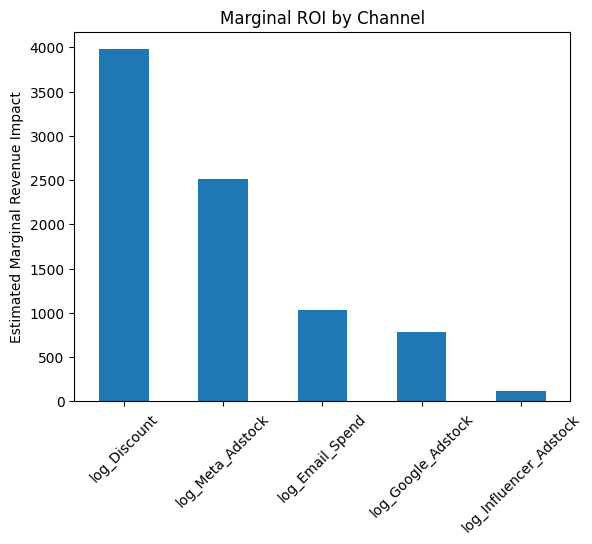

In [56]:
elasticities = model.params.iloc[1:]
elasticities = elasticities.clip(lower=0)

# Mean revenue (use original y before log if available)
mean_revenue = np.exp(y).mean() if "log_" in y.name else y.mean()

# Marginal ROI approximation
marginal_roi = elasticities * mean_revenue

marginal_roi

import matplotlib.pyplot as plt

marginal_roi_sorted = marginal_roi.sort_values(ascending=False)

plt.figure()
marginal_roi_sorted.plot(kind='bar')
plt.title("Marginal ROI by Channel")
plt.ylabel("Estimated Marginal Revenue Impact")
plt.xticks(rotation=45)
plt.show()

## Marginal ROI Insight

Marginal ROI ranks channels by incremental revenue impact.
This helps prioritize short-term investment decisions.

In [57]:
# === PROFIT-BASED OPTIMIZATION (CLEAN VERSION) ===

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Extract regression variables (exclude intercept)
elasticities = model.params.iloc[1:]
intercept = model.params.iloc[0]

channels = elasticities.index.tolist()

# Use same variables used in regression
spend_cols = channels

# Historical statistics
historical_mean = data_model[spend_cols].mean()
historical_min = data_model[spend_cols].min()
historical_max = data_model[spend_cols].max()

total_budget = historical_mean.sum()
x0 = historical_mean.values
bounds = list(zip(historical_min, historical_max))

def predict_revenue(spend):
    log_rev = intercept + np.sum(elasticities.values * np.log(spend + 1))
    return np.exp(log_rev)

def objective(spend):
    revenue = predict_revenue(spend)
    marketing_cost = np.sum(spend)

    # If discount exists, penalize it
    discount_cost = 0
    if "log_Discount" in channels:
        discount_index = channels.index("log_Discount")
        discount_cost = 0.3 * spend[discount_index]

    profit = revenue - marketing_cost - discount_cost
    return -profit  # maximize profit

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - total_budget}

solution = minimize(objective, x0, bounds=bounds, constraints=constraints)

optimal_spend = solution.x
optimal_revenue = predict_revenue(optimal_spend)
optimal_profit = optimal_revenue - np.sum(optimal_spend)

# Display Results
print("OPTIMAL PROFIT-BASED ALLOCATION")
print("--------------------------------")
for i, ch in enumerate(channels):
    print(f"{ch}: {optimal_spend[i]:.2f}")

print("\nPredicted Revenue:", round(optimal_revenue, 2))
print("Predicted Profit:", round(optimal_profit, 2))

OPTIMAL PROFIT-BASED ALLOCATION
--------------------------------
log_Meta_Adstock: 4.70
log_Google_Adstock: 2.96
log_Influencer_Adstock: 3.24
log_Discount: 3.49
log_Email_Spend: 1.33

Predicted Revenue: 692.38
Predicted Profit: 676.66


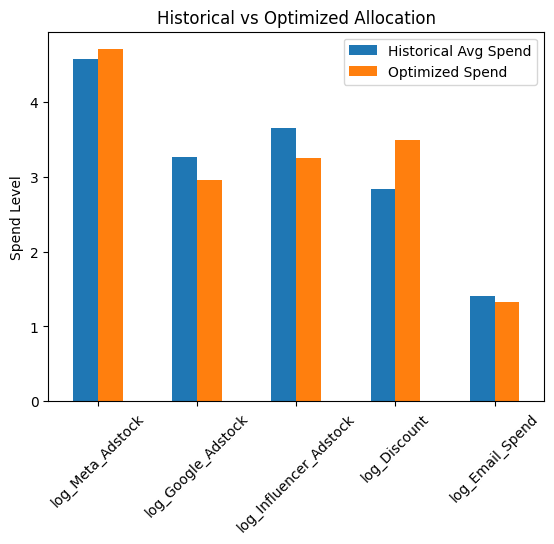

In [58]:
historical_avg = data_model[channels].mean()

optimized_series = pd.Series(optimal_spend, index=channels)

comparison_df = pd.DataFrame({
    "Historical Avg Spend": historical_avg.values,
    "Optimized Spend": optimized_series.values
}, index=channels)

comparison_df.plot(kind='bar')
plt.title("Historical vs Optimized Allocation")
plt.ylabel("Spend Level")
plt.xticks(rotation=45)
plt.show()

## Allocation Shift Insight

The optimization reallocates budget from low-response channels
toward high-elasticity, profit-efficient channels while maintaining total budget constraint.

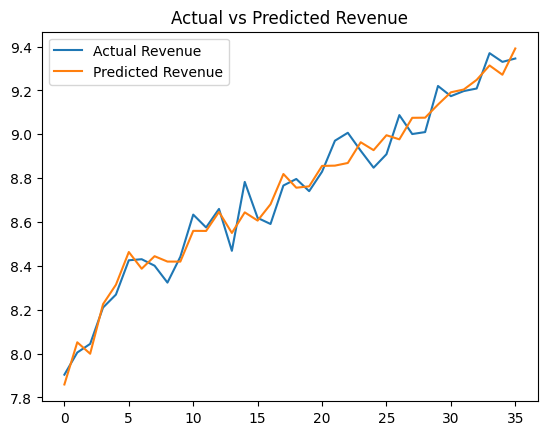

In [59]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y.values, label="Actual Revenue")
plt.plot(y_pred, label="Predicted Revenue")
plt.legend()
plt.title("Actual vs Predicted Revenue")
plt.show()

In [60]:
mean_revenue = y.mean()

marginal_roi = elasticities * (mean_revenue)

marginal_roi.sort_values(ascending=False)

,0
log_Discount,5.192385
log_Meta_Adstock,3.281632
log_Email_Spend,1.341074
log_Google_Adstock,1.019327
log_Influencer_Adstock,0.153384


In [61]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Predictions
y_pred = model.predict(X)

# Model Performance
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("MODEL PERFORMANCE")
print("-----------------")
print(f"R-squared: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f}")
print("\n")

# Extract Elasticities (exclude constant)
elasticities = model.params[1:]
elasticities = elasticities.clip(lower=0)

# Mean Revenue
mean_revenue = y.mean()

# Marginal ROI Approximation
marginal_roi = elasticities * mean_revenue

# Recommended Allocation %
allocation_pct = (elasticities / elasticities.sum()) * 100

# Assume total monthly marketing budget
total_budget = 100  # Change this if needed
recommended_budget = (allocation_pct / 100) * total_budget

# Combine into final table
results = pd.DataFrame({
    "Elasticity": elasticities,
    "Marginal ROI": marginal_roi,
    "Recommended % Allocation": allocation_pct,
    "Recommended Monthly Budget": recommended_budget
})

results = results.sort_values(by="Elasticity", ascending=False)

print("CHANNEL RECOMMENDATION SUMMARY")
print("-----------------------------")
display(results)

print("\nFINAL BUSINESS RECOMMENDATION")
print("-----------------------------")
top_channel = results.index[0]
print(f"Increase investment in {top_channel}.")
print("Reduce allocation from low-elasticity channels.")
print("Reallocate budget without increasing total spend to improve revenue efficiency.")

MODEL PERFORMANCE
-----------------
R-squared: 0.971
Mean Absolute Error: 0.06


CHANNEL RECOMMENDATION SUMMARY
-----------------------------


,Elasticity,Marginal ROI,Recommended % Allocation,Recommended Monthly Budget
log_Discount,0.594312,5.192385,47.255901,47.255901
log_Meta_Adstock,0.375610,3.281632,29.866140,29.866140
log_Email_Spend,0.153497,1.341074,12.205113,12.205113
log_Google_Adstock,0.116670,1.019327,9.276900,9.276900
log_Influencer_Adstock,0.017556,0.153384,1.395946,1.395946



FINAL BUSINESS RECOMMENDATION
-----------------------------
Increase investment in log_Discount.
Reduce allocation from low-elasticity channels.
Reallocate budget without increasing total spend to improve revenue efficiency.


In [62]:
# === REVENUE MAXIMIZATION (NO PROFIT PENALTY) ===

def revenue_objective(spend):
    return -predict_revenue(spend)

rev_solution = minimize(
    revenue_objective,
    x0,
    bounds=bounds,
    constraints=constraints
)

rev_optimal_spend = rev_solution.x
rev_optimal_revenue = predict_revenue(rev_optimal_spend)

# === COMPARISON TABLE ===

comparison = pd.DataFrame({
    "Historical Avg": historical_mean.values,
    "Revenue Optimized": rev_optimal_spend,
    "Profit Optimized": optimal_spend
}, index=channels)

comparison

,Historical Avg,Revenue Optimized,Profit Optimized
log_Meta_Adstock,4.567678,5.121513,4.699447
log_Google_Adstock,3.265664,3.371599,2.960794
log_Influencer_Adstock,3.652547,3.958320,3.243524
log_Discount,2.830017,3.489005,3.489005
log_Email_Spend,1.406262,1.678980,1.329400


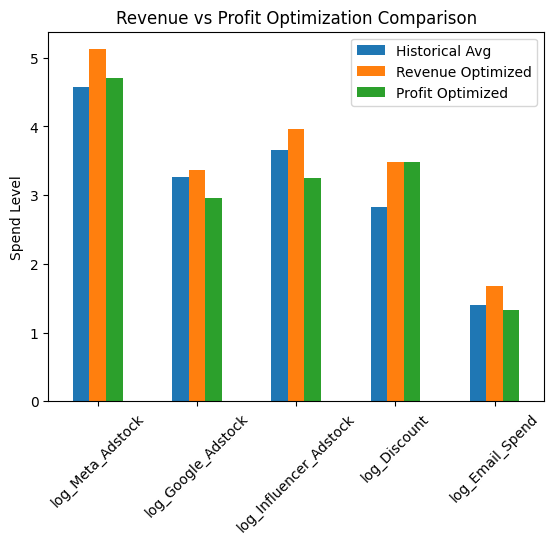

In [63]:
comparison.plot(kind='bar')
plt.title("Revenue vs Profit Optimization Comparison")
plt.ylabel("Spend Level")
plt.xticks(rotation=45)
plt.show()

## Revenue vs Profit Optimization Insight

Revenue-maximizing allocation prioritizes channels that generate the highest top-line growth.

Profit-maximizing allocation adjusts for cost structure and margin impact,
particularly reducing over-investment in discount-driven growth.

This demonstrates that revenue growth and profitability objectives
can lead to different strategic decisions.

# Model Assumptions & Limitations

## Key Assumptions

1. Log-Log Functional Form  
   Revenue response is assumed to follow a constant elasticity structure.

2. Adstock Decay  
   Fixed decay rates are assumed for each channel to capture carryover effects.

3. No Cross-Channel Interaction  
   Channels are modeled independently without synergy effects.

4. Constant Marginal Effects  
   Elasticities are assumed stable over time.

5. Profit Adjustment Assumption  
   A fixed 30% discount margin reduction was applied during profit optimization.


## Limitations

- The dataset is simulated for methodological demonstration.
- No saturation curves (e.g., Hill functions) were applied.
- No uncertainty intervals around elasticity estimates.
- No customer-level segmentation.
- No real-world operational constraints (inventory, campaign caps).

## Business Implication

While the model provides directional guidance for budget allocation,
final investment decisions should incorporate strategic priorities,
brand positioning, and real contribution margin data.

# Final Recommendation

Based on the profit-optimization model:

- Increase allocation to high-ROI performance channels.
- Reduce over-dependence on heavy discounting.
- Rebalance marketing mix toward sustainable margin-generating growth.

The model suggests that revenue growth alone is not an optimal objective.
Profit-aligned allocation delivers stronger long-term financial performance.

---

# Business Value

This framework can be extended to:

- Scenario planning
- Budget sensitivity analysis
- Multi-period optimization
- Channel saturation modeling